# CSE-CIC-IDS2018 — Model Training with Optuna

Optimized to run **locally** (VS Code / Jupyter) — no Google Colab dependencies.

Instead of hand-picking one algorithm and guessing hyperparameters, this notebook:

1. Defines a **single Optuna search space** covering 5 algorithms: Decision Tree, Random Forest,
   Histogram Gradient Boosting, XGBoost, and AdaBoost — Optuna picks both the algorithm *and*
   its hyperparameters per trial.
2. Runs the search on a **stratified subsample** of the training set (fast iteration), scoring
   trials with cross-validated **macro F1** (appropriate for this imbalanced, multi-class problem).
3. Selects the **3 best-performing algorithms** found during the search.
4. Retrains each of those 3 with its best hyperparameters on the **full** balanced training set,
   evaluates on the held-out test set, and saves models + metrics + confusion matrices.

> Requires: `pip install optuna xgboost`

> Note on Gradient Boosting: this notebook uses scikit-learn's `HistGradientBoostingClassifier`
> rather than the classic `GradientBoostingClassifier`. It is the modern, histogram-based
> implementation of the same algorithm family (comparable to LightGBM/XGBoost in speed) and is
> dramatically faster on datasets of this size — the classic version would be impractically slow
> to tune with Optuna on hundreds of thousands of rows.

## 1. Configuration & Setup

In [1]:
import os
import time
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

m:\IDS\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_PATH = Path(r"M:\IDS\c_filesnew")

PROCESSED_DATA_PATH = PROJECT_PATH / "Processed_Data"
RESULTS_PATH   = PROJECT_PATH / "Results"
MODELS_PATH    = RESULTS_PATH / "Models"
FIGURES_PATH   = RESULTS_PATH / "Figures"
TABLES_PATH    = RESULTS_PATH / "Tables"

for p in [MODELS_PATH, FIGURES_PATH, TABLES_PATH]:
    p.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
CV_FOLDS = 3
N_TRIALS = 60          # increase for a more thorough search
HPO_SAMPLE_SIZE = 100_000   # rows used for the Optuna search (full data used for final training)

## 2. Load Data

In [3]:
train = pd.read_parquet(PROCESSED_DATA_PATH / "balanced_train_selected.parquet")
test = pd.read_parquet(PROCESSED_DATA_PATH / "test_selected.parquet")

X_train = train.drop(columns=["Label"])
y_train = train["Label"]

X_test = test.drop(columns=["Label"])
y_test = test["Label"]

N_CLASSES = y_train.nunique()

print("Train:", X_train.shape, " Test:", X_test.shape, " Classes:", N_CLASSES)

Train: (257287, 30)  Test: (200498, 30)  Classes: 15


In [4]:
# Stratified subsample for fast hyperparameter search
if len(X_train) > HPO_SAMPLE_SIZE:
    X_hpo, _, y_hpo, _ = train_test_split(
        X_train, y_train,
        train_size=HPO_SAMPLE_SIZE,
        stratify=y_train,
        random_state=RANDOM_STATE,
    )
else:
    X_hpo, y_hpo = X_train, y_train

print("HPO search sample:", X_hpo.shape)

HPO search sample: (100000, 30)


## 3. Unified Search Space

`suggest_hyperparameters` asks Optuna for the parameters relevant to whichever algorithm the
trial picked. `instantiate_model` turns a finished set of parameters (prefixed, e.g. `rf_max_depth`)
back into a ready-to-fit estimator — used both inside the objective and later for the final
retraining of the top 3 algorithms, so the model-building logic only lives in one place.

In [5]:
ALGORITHMS = ["decision_tree", "random_forest", "hist_gradient_boosting", "xgboost", "adaboost"]

ALGO_DISPLAY_NAMES = {
    "decision_tree": "DecisionTree",
    "random_forest": "RandomForest",
    "hist_gradient_boosting": "HistGradientBoosting",
    "xgboost": "XGBoost",
    "adaboost": "AdaBoost",
}

PREFIXES = {
    "decision_tree": "dt_",
    "random_forest": "rf_",
    "hist_gradient_boosting": "hgb_",
    "xgboost": "xgb_",
    "adaboost": "ada_",
}


def suggest_hyperparameters(trial, algorithm):
    """Ask Optuna for the hyperparameters relevant to `algorithm`."""
    if algorithm == "decision_tree":
        return {
            "dt_max_depth": trial.suggest_int("dt_max_depth", 3, 30),
            "dt_min_samples_split": trial.suggest_int("dt_min_samples_split", 2, 20),
            "dt_min_samples_leaf": trial.suggest_int("dt_min_samples_leaf", 1, 20),
            "dt_criterion": trial.suggest_categorical("dt_criterion", ["gini", "entropy"]),
            "dt_class_weight": trial.suggest_categorical("dt_class_weight", [None, "balanced"]),
        }

    if algorithm == "random_forest":
        return {
            "rf_n_estimators": trial.suggest_int("rf_n_estimators", 100, 500, step=50),
            "rf_max_depth": trial.suggest_int("rf_max_depth", 5, 30),
            "rf_min_samples_split": trial.suggest_int("rf_min_samples_split", 2, 20),
            "rf_min_samples_leaf": trial.suggest_int("rf_min_samples_leaf", 1, 10),
            "rf_max_features": trial.suggest_categorical("rf_max_features", ["sqrt", "log2"]),
            "rf_class_weight": trial.suggest_categorical("rf_class_weight", [None, "balanced"]),
        }

    if algorithm == "hist_gradient_boosting":
        return {
            "hgb_max_iter": trial.suggest_int("hgb_max_iter", 100, 400, step=50),
            "hgb_learning_rate": trial.suggest_float("hgb_learning_rate", 0.01, 0.3, log=True),
            "hgb_max_depth": trial.suggest_int("hgb_max_depth", 3, 15),
            "hgb_max_leaf_nodes": trial.suggest_int("hgb_max_leaf_nodes", 15, 63),
            "hgb_l2_regularization": trial.suggest_float("hgb_l2_regularization", 1e-4, 1.0, log=True),
        }

    if algorithm == "xgboost":
        return {
            "xgb_n_estimators": trial.suggest_int("xgb_n_estimators", 100, 500, step=50),
            "xgb_max_depth": trial.suggest_int("xgb_max_depth", 3, 12),
            "xgb_learning_rate": trial.suggest_float("xgb_learning_rate", 0.01, 0.3, log=True),
            "xgb_subsample": trial.suggest_float("xgb_subsample", 0.6, 1.0),
            "xgb_colsample_bytree": trial.suggest_float("xgb_colsample_bytree", 0.6, 1.0),
            "xgb_min_child_weight": trial.suggest_int("xgb_min_child_weight", 1, 10),
            "xgb_gamma": trial.suggest_float("xgb_gamma", 0.0, 5.0),
            "xgb_reg_alpha": trial.suggest_float("xgb_reg_alpha", 1e-8, 10.0, log=True),
            "xgb_reg_lambda": trial.suggest_float("xgb_reg_lambda", 1e-8, 10.0, log=True),
        }

    # adaboost
    return {
        "ada_base_max_depth": trial.suggest_int("ada_base_max_depth", 1, 5),
        "ada_n_estimators": trial.suggest_int("ada_n_estimators", 50, 300, step=25),
        "ada_learning_rate": trial.suggest_float("ada_learning_rate", 0.01, 2.0, log=True),
    }


def instantiate_model(algorithm, params, n_classes, random_state=RANDOM_STATE):
    """Build a ready-to-fit estimator from a (possibly prefixed) parameter dict."""
    prefix = PREFIXES[algorithm]
    p = {k[len(prefix):]: v for k, v in params.items() if k.startswith(prefix)}

    if algorithm == "decision_tree":
        return DecisionTreeClassifier(**p, random_state=random_state)

    if algorithm == "random_forest":
        return RandomForestClassifier(**p, random_state=random_state, n_jobs=-1)

    if algorithm == "hist_gradient_boosting":
        return HistGradientBoostingClassifier(**p, random_state=random_state)

    if algorithm == "xgboost":
        return XGBClassifier(
            **p,
            objective="multi:softprob",
            num_class=n_classes,
            eval_metric="mlogloss",
            tree_method="hist",
            random_state=random_state,
            n_jobs=-1,
        )

    if algorithm == "adaboost":
        base_depth = p.pop("base_max_depth")
        base_estimator = DecisionTreeClassifier(max_depth=base_depth, random_state=random_state)
        return AdaBoostClassifier(estimator=base_estimator, **p, random_state=random_state)

    raise ValueError(f"Unknown algorithm: {algorithm}")

## 4. Optuna Objective & Study

In [6]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    algorithm = trial.suggest_categorical("algorithm", ALGORITHMS)
    params = suggest_hyperparameters(trial, algorithm)
    model = instantiate_model(algorithm, params, n_classes=N_CLASSES, random_state=RANDOM_STATE)

    scores = cross_val_score(
        model, X_hpo, y_hpo,
        cv=cv, scoring="f1_macro", n_jobs=1,
    )
    return float(scores.mean())

In [7]:
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(),
    study_name="ids2018_algorithm_and_hpo_search",
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best trial:")
print("  Value (macro F1):", study.best_value)
print("  Params:", study.best_params)

Best trial: 31. Best value: 0.96696: 100%|██████████| 60/60 [59:22<00:00, 59.38s/it]  

Best trial:
  Value (macro F1): 0.9669599299594798
  Params: {'algorithm': 'random_forest', 'rf_n_estimators': 400, 'rf_max_depth': 22, 'rf_min_samples_split': 9, 'rf_min_samples_leaf': 3, 'rf_max_features': 'sqrt', 'rf_class_weight': 'balanced'}


In [8]:
joblib.dump(study, MODELS_PATH / "optuna_study.pkl")

trials_df = study.trials_dataframe()
trials_df.to_csv(TABLES_PATH / "optuna_trials.csv", index=False)

trials_df.head()

,number,value,datetime_start,datetime_complete,duration,params_ada_base_max_depth,params_ada_learning_rate,params_ada_n_estimators,params_algorithm,params_dt_class_weight,...,params_xgb_colsample_bytree,params_xgb_gamma,params_xgb_learning_rate,params_xgb_max_depth,params_xgb_min_child_weight,params_xgb_n_estimators,params_xgb_reg_alpha,params_xgb_reg_lambda,params_xgb_subsample,state
0,0,0.796224,2026-07-20 14:57:29.928665,2026-07-20 14:57:37.828936,0 days 00:00:07.900271,NaN,NaN,NaN,random_forest,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
1,1,0.898568,2026-07-20 14:57:37.830938,2026-07-20 15:02:10.652285,0 days 00:04:32.821347,3.0,0.255795,125.0,adaboost,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
2,2,0.217302,2026-07-20 15:02:10.655357,2026-07-20 15:04:44.524195,0 days 00:02:33.868838,1.0,0.230762,175.0,adaboost,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
3,3,0.947797,2026-07-20 15:04:44.526722,2026-07-20 15:18:56.224446,0 days 00:14:11.697724,5.0,0.050226,250.0,adaboost,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
4,4,0.946029,2026-07-20 15:18:56.227447,2026-07-20 15:19:01.896784,0 days 00:00:05.669337,NaN,NaN,NaN,random_forest,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE


## 5. Rank Algorithms & Pick the Top 3

In [9]:
completed = trials_df[trials_df["state"] == "COMPLETE"]

algo_best = (
    completed.groupby("params_algorithm")["value"]
    .max()
    .sort_values(ascending=False)
)
algo_best.index = algo_best.index.map(ALGO_DISPLAY_NAMES)

print("Best macro-F1 achieved per algorithm during the search:")
algo_best

Best macro-F1 achieved per algorithm during the search:


params_algorithm
RandomForest            0.966960
HistGradientBoosting    0.958804
AdaBoost                0.949414
XGBoost                 0.945463
DecisionTree            0.938216
Name: value, dtype: float64

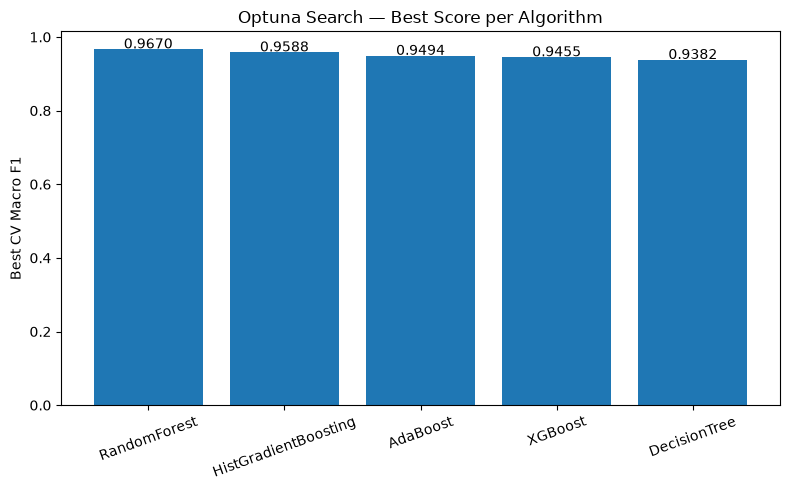

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(algo_best.index, algo_best.values)
plt.ylabel("Best CV Macro F1")
plt.title("Optuna Search — Best Score per Algorithm")
plt.xticks(rotation=20)
for i, v in enumerate(algo_best.values):
    plt.text(i, v + 0.002, f"{v:.4f}", ha="center")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "optuna_algorithm_comparison.png", dpi=200)
plt.show()

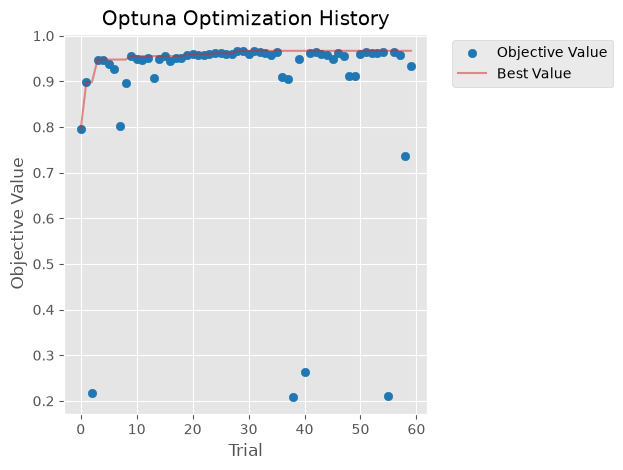

In [11]:
ax = optuna.visualization.matplotlib.plot_optimization_history(study)
ax.set_title("Optuna Optimization History")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "optuna_optimization_history.png", dpi=200, bbox_inches="tight")
plt.show()

In [12]:
TOP_K_ALGOS = 3
top3_algorithms_display = algo_best.head(TOP_K_ALGOS).index.tolist()

reverse_display = {v: k for k, v in ALGO_DISPLAY_NAMES.items()}
top3_algorithms = [reverse_display[name] for name in top3_algorithms_display]

print(f"Top {TOP_K_ALGOS} algorithms selected by Optuna:", top3_algorithms_display)

Top 3 algorithms selected by Optuna: ['RandomForest', 'HistGradientBoosting', 'AdaBoost']


In [13]:
best_trial_per_algo = {}

for algo in top3_algorithms:
    subset = completed[completed["params_algorithm"] == algo]
    best_row = subset.loc[subset["value"].idxmax()]
    best_trial_per_algo[algo] = study.trials[int(best_row["number"])]

for algo, trial in best_trial_per_algo.items():
    print(f"{ALGO_DISPLAY_NAMES[algo]} -> CV Macro F1 = {trial.value:.4f}")
    print("   params:", trial.params)

RandomForest -> CV Macro F1 = 0.9670
   params: {'algorithm': 'random_forest', 'rf_n_estimators': 400, 'rf_max_depth': 22, 'rf_min_samples_split': 9, 'rf_min_samples_leaf': 3, 'rf_max_features': 'sqrt', 'rf_class_weight': 'balanced'}
HistGradientBoosting -> CV Macro F1 = 0.9588
   params: {'algorithm': 'hist_gradient_boosting', 'hgb_max_iter': 100, 'hgb_learning_rate': 0.03432170835605239, 'hgb_max_depth': 7, 'hgb_max_leaf_nodes': 47, 'hgb_l2_regularization': 0.034369295193494936}
AdaBoost -> CV Macro F1 = 0.9494
   params: {'algorithm': 'adaboost', 'ada_base_max_depth': 5, 'ada_n_estimators': 200, 'ada_learning_rate': 1.8343641469560932}


## 6. Retrain the Top 3 Models on the Full Training Set

Each selected algorithm is rebuilt with its best hyperparameters and retrained on the **entire**
balanced training set, then evaluated once on the held-out test set.

In [14]:
def evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    print("="*70)
    print(f"Training {model_name}")
    print("="*70)

    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start

    accuracy = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    report_df = pd.DataFrame(
        classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    ).transpose()
    report_df.to_csv(MODELS_PATH / f"{model_name}_classification_report.csv")

    metrics_df = pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy],
        "Macro Precision": [precision_macro],
        "Macro Recall": [recall_macro],
        "Macro F1": [macro_f1],
        "Weighted F1": [weighted_f1],
        "Training Time (s)": [train_time],
        "Prediction Time (s)": [pred_time],
    })
    metrics_df.to_csv(MODELS_PATH / f"{model_name}_metrics.csv", index=False)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 10))
    ConfusionMatrixDisplay(cm).plot(cmap="Blues", values_format="d")
    plt.title(model_name)
    plt.savefig(MODELS_PATH / f"{model_name}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.close()

    joblib.dump(model, MODELS_PATH / f"{model_name}.pkl")

    print(metrics_df)
    return metrics_df

In [15]:
final_results = []

for algo, trial in best_trial_per_algo.items():
    model_name = ALGO_DISPLAY_NAMES[algo] + "_Tuned"
    model = instantiate_model(algo, trial.params, n_classes=N_CLASSES, random_state=RANDOM_STATE)

    # persist the winning hyperparameters alongside the model
    with open(MODELS_PATH / f"{model_name}_best_params.json", "w") as f:
        json.dump(trial.params, f, indent=2, default=str)

    metrics = evaluate_model(model, model_name, X_train, y_train, X_test, y_test)
    final_results.append(metrics)

Training RandomForest_Tuned
                Model  Accuracy  Macro Precision  Macro Recall  Macro F1  \
0  RandomForest_Tuned  0.989456          0.91428      0.932268  0.910514   

   Weighted F1  Training Time (s)  Prediction Time (s)  
0      0.99079          37.731719             3.225412  
Training HistGradientBoosting_Tuned
                        Model  Accuracy  Macro Precision  Macro Recall  \
0  HistGradientBoosting_Tuned  0.992165         0.927708      0.950784   

   Macro F1  Weighted F1  Training Time (s)  Prediction Time (s)  
0  0.935331     0.992988          14.174031             3.445086  
Training AdaBoost_Tuned
            Model  Accuracy  Macro Precision  Macro Recall  Macro F1  \
0  AdaBoost_Tuned  0.989471          0.90043      0.905168  0.899769   

   Weighted F1  Training Time (s)  Prediction Time (s)  
0     0.990148         912.900673            14.301267  


<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

## 7. Final Comparison of the Top 3 Tuned Models

In [16]:
comparison = pd.concat(final_results, ignore_index=True).sort_values(
    "Macro F1", ascending=False
).reset_index(drop=True)

comparison.to_csv(TABLES_PATH / "model_comparison.csv", index=False)
comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (s),Prediction Time (s)
0,HistGradientBoosting_Tuned,0.992165,0.927708,0.950784,0.935331,0.992988,14.174031,3.445086
1,RandomForest_Tuned,0.989456,0.914280,0.932268,0.910514,0.990790,37.731719,3.225412
2,AdaBoost_Tuned,0.989471,0.900430,0.905168,0.899769,0.990148,912.900673,14.301267


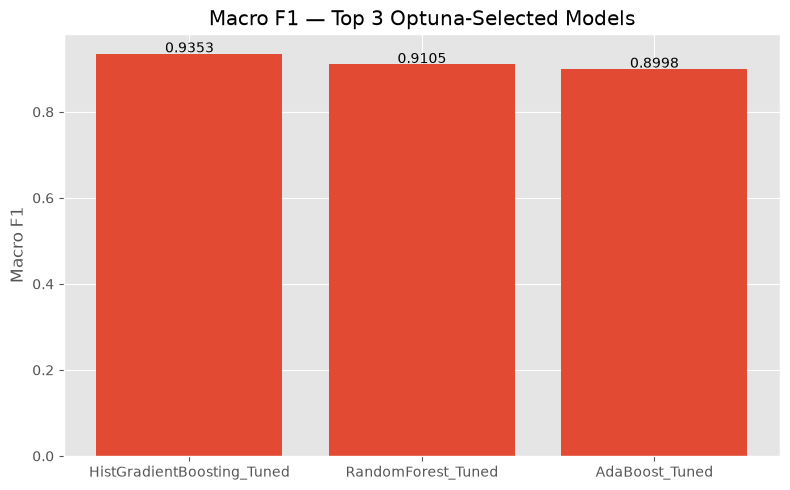

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["Macro F1"])
plt.title("Macro F1 — Top 3 Optuna-Selected Models")
plt.ylabel("Macro F1")
for i, v in enumerate(comparison["Macro F1"]):
    plt.text(i, v + 0.003, f"{v:.4f}", ha="center")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "macro_f1_comparison.png", dpi=200)
plt.show()

---
**Outputs (under `Results/`):**
- `Models/optuna_study.pkl` — the full Optuna study (all trials, reusable/resumable)
- `Tables/optuna_trials.csv` — every trial's algorithm, params, and score
- `Models/<Model>_Tuned.pkl`, `_metrics.csv`, `_classification_report.csv`, `_confusion_matrix.png`,
  `_best_params.json` — one set per selected algorithm
- `Tables/model_comparison.csv` — final ranked comparison table

Feed straight into `05_Compare_All_Models.ipynb` for the consolidated report.

In [19]:
train_vs_test_rows = []

for algo, trial in best_trial_per_algo.items():
    model_name = ALGO_DISPLAY_NAMES[algo] + "_Tuned"
    model = joblib.load(MODELS_PATH / f"{model_name}.pkl")

    y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_macro_f1 = f1_score(y_train, y_train_pred, average="macro", zero_division=0)

    test_row = comparison[comparison["Model"] == model_name].iloc[0]

    train_vs_test_rows.append({
        "Model": model_name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_row["Accuracy"],
        "Train Macro F1": train_macro_f1,
        "Test Macro F1": test_row["Macro F1"],
        "Accuracy Gap": train_accuracy - test_row["Accuracy"],
        "Macro F1 Gap": train_macro_f1 - test_row["Macro F1"],
    })

train_vs_test = pd.DataFrame(train_vs_test_rows).sort_values("Accuracy Gap", ascending=False)
train_vs_test.to_csv(TABLES_PATH / "train_vs_test_gap.csv", index=False)

print(train_vs_test)

for _, row in train_vs_test.iterrows():
    if row["Accuracy Gap"] > 0.05:
        print(f"\nNote: {row['Model']} shows a notable train/test gap ({row['Accuracy Gap']:.4f}) — possible overfitting.")

                        Model  Train Accuracy  Test Accuracy  Train Macro F1  \
0          RandomForest_Tuned        0.993412       0.989456        0.977624   
1  HistGradientBoosting_Tuned        0.995013       0.992165        0.983876   
2              AdaBoost_Tuned        0.984267       0.989471        0.964157   

   Test Macro F1  Accuracy Gap  Macro F1 Gap  
0       0.910514      0.003956      0.067110  
1       0.935331      0.002849      0.048545  
2       0.899769     -0.005205      0.064388  
